# CNN Training Strategy 2: Progressive Dataset Revelation

CIFAR-10: 60,000 32x32 colour images in 10 classes
- 50,000 training images | 10,000 test images
- Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

**Strategy**: Train the model by progressively revealing more of the dataset:
- Stage 1: 10% of training data (5,000 images)
- Stage 2: 25% of training data (12,500 images)
- Stage 3: 50% of training data (25,000 images)
- Stage 4: 75% of training data (37,500 images)
- Stage 5: 100% of training data (50,000 images)

Each stage trains for 5 epochs, totalling 25 epochs — same as the full dataset strategy.

### Importing the libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [3]:
tf.__version__

'2.19.0'

In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

## Part 1 - Data Preprocessing

### Loading the CIFAR-10 dataset

In [9]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()


### Preprocessing the Test set (stays the same for all stages)

In [12]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow(x_test, y_test, batch_size=64)

### Define the training data augmentation pipeline

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

### Define the progressive data fractions and epochs per stage

In [18]:
# Progressive revelation schedule: fraction of data to use at each stage
progressive_fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
epochs_per_stage = 5  # 5 stages × 5 epochs = 25 total epochs

print("Progressive Dataset Revelation Schedule:")
print("="*50)
for i, frac in enumerate(progressive_fractions):
    n_samples = int(len(x_train) * frac)
    print(f"Stage {i+1}: {frac*100:.0f}% → {n_samples:,} samples ({epochs_per_stage} epochs)")
print(f"\nTotal epochs: {len(progressive_fractions) * epochs_per_stage}")

Progressive Dataset Revelation Schedule:
Stage 1: 10% → 5,000 samples (5 epochs)
Stage 2: 25% → 12,500 samples (5 epochs)
Stage 3: 50% → 25,000 samples (5 epochs)
Stage 4: 75% → 37,500 samples (5 epochs)
Stage 5: 100% → 50,000 samples (5 epochs)

Total epochs: 25


## Part 2 - Building the CNN

Same architecture as the full dataset training strategy.

In [21]:
    cnn = models.Sequential()
    
    # First Convolution + Pooling
    cnn.add(layers.Input(shape=(32, 32, 3)))
    cnn.add(layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
    cnn.add(layers.BatchNormalization())
    cnn.add(layers.MaxPool2D(pool_size=2, strides=2))
    
    # Second Convolution + Pooling
    cnn.add(layers.Conv2D(filters=64, kernel_size=3, activation='relu'))
    cnn.add(layers.BatchNormalization())
    cnn.add(layers.MaxPool2D(pool_size=2, strides=2))
    
    # Third Convolution + Pooling
    cnn.add(layers.Conv2D(filters=128, kernel_size=3, activation='relu'))
    cnn.add(layers.BatchNormalization())
    cnn.add(layers.MaxPool2D(pool_size=2, strides=2))
    
    # Flattening
    cnn.add(layers.Flatten())
    
    # Full Connection
    cnn.add(layers.Dense(units=256, activation='relu'))
    cnn.add(layers.Dropout(0.5))
    cnn.add(layers.Dense(units=128, activation='relu'))
    cnn.add(layers.Dropout(0.3))
    
    # Output Layer
    cnn.add(layers.Dense(units=10, activation='softmax'))
    


In [23]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,658 (1014.29 KB)

 Trainable params: 259,210 (1012.54 KB)

 Non-trainable params: 448 (1.75 KB)

### Compiling the CNN
Using `sparse_categorical_crossentropy` for multi-class (instead of `binary_crossentropy`)

In [26]:
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## Part 3 - Progressive Training

The model is trained in stages. At each stage, a larger subset of the training data is revealed.
The key idea is that the model first learns from a small subset and gradually sees more data, 
allowing it to refine its learned features progressively.

In [29]:
# Shuffle the training data first (to ensure random subsets)
np.random.seed(42)
shuffle_indices = np.random.permutation(len(x_train))
x_train_shuffled = x_train[shuffle_indices]
y_train_shuffled = y_train[shuffle_indices]

# Store full training history across all stages
full_history = {
    'accuracy': [],
    'val_accuracy': [],
    'loss': [],
    'val_loss': []
}

stage_boundaries = []  # to mark where each stage starts in the plot

for stage_idx, fraction in enumerate(progressive_fractions):
    n_samples = int(len(x_train_shuffled) * fraction)
    
    # Take the first n_samples (progressive revelation — each stage includes all previous data)
    x_subset = x_train_shuffled[:n_samples]
    y_subset = y_train_shuffled[:n_samples]
    
    # Create augmented training set for this stage
    training_set = train_datagen.flow(x_subset, y_subset, batch_size=64)
    
    print(f"\n{'='*60}")
    print(f"STAGE {stage_idx + 1}/{len(progressive_fractions)}: "
          f"Training with {fraction*100:.0f}% data ({n_samples:,} samples)")
    print(f"{'='*60}")
    
    # Record stage boundary for plotting
    stage_boundaries.append(len(full_history['accuracy']))
    
    # Train for epochs_per_stage epochs
    history = cnn.fit(
        x=training_set,
        validation_data=test_set,
        epochs=epochs_per_stage
    )
    
    # Accumulate history
    for key in full_history:
        full_history[key].extend(history.history[key])
    
    # Print stage summary
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"\nStage {stage_idx + 1} Complete:")
    print(f"  Train Accuracy: {final_train_acc:.4f}")
    print(f"  Val Accuracy:   {final_val_acc:.4f}")

print(f"\n{'='*60}")
print("Progressive training complete!")
print(f"{'='*60}")


STAGE 1/5: Training with 10% data (5,000 samples)
Epoch 1/5


D:\ANACONDA\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.1750 - loss: 2.6801 - val_accuracy: 0.1356 - val_loss: 2.4462
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.2584 - loss: 1.9974 - val_accuracy: 0.1000 - val_loss: 2.8992
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.3125 - loss: 1.8793 - val_accuracy: 0.1561 - val_loss: 2.5424
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.3456 - loss: 1.7827 - val_accuracy: 0.2102 - val_loss: 2.2309
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.3415 - loss: 1.7811 - val_accuracy: 0.2857 - val_loss: 1.8975

Stage 1 Complete:
  Train Accuracy: 0.3532
  Val Accuracy:   0.2857

STAGE 2/5: Training with 25% data (12,500 samples)
Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.3921 - loss: 1.6763 - val_accuracy: 0.4622 - val_loss: 1.4960
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.4202 - loss: 1.5828 - val_accuracy: 0.4938 - val_loss: 1.4298
Epo

## Part 4 - Evaluating the Results

### Plotting Training & Validation Accuracy / Loss with Stage Boundaries

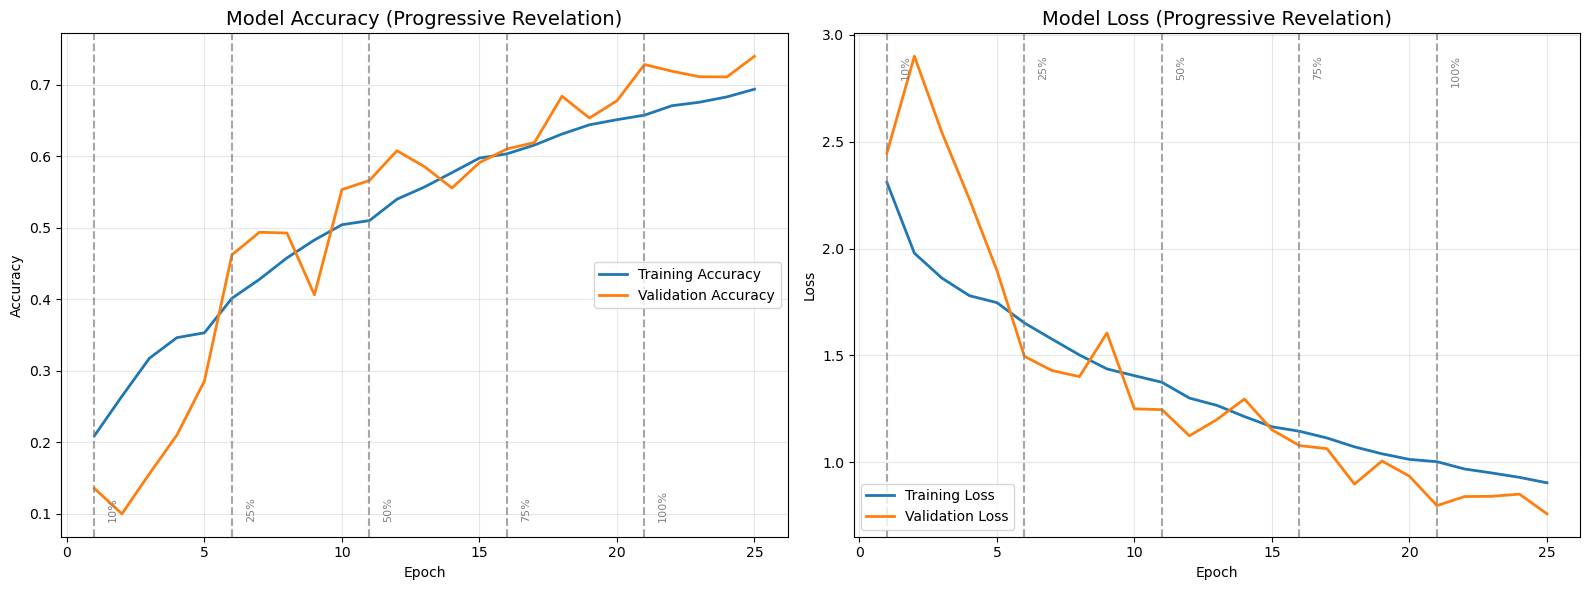

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, len(full_history['accuracy']) + 1)

# --- Accuracy plot ---
ax1.plot(epochs_range, full_history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(epochs_range, full_history['val_accuracy'], label='Validation Accuracy', linewidth=2)

# Add stage boundary lines
for i, boundary in enumerate(stage_boundaries):
    frac = progressive_fractions[i]
    ax1.axvline(x=boundary + 1, color='gray', linestyle='--', alpha=0.7)
    ax1.text(boundary + 1.5, ax1.get_ylim()[0] + 0.02, f'{frac*100:.0f}%',
             fontsize=8, color='gray', rotation=90, va='bottom')

ax1.set_title('Model Accuracy (Progressive Revelation)', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Loss plot ---
ax2.plot(epochs_range, full_history['loss'], label='Training Loss', linewidth=2)
ax2.plot(epochs_range, full_history['val_loss'], label='Validation Loss', linewidth=2)

# Add stage boundary lines
for i, boundary in enumerate(stage_boundaries):
    frac = progressive_fractions[i]
    ax2.axvline(x=boundary + 1, color='gray', linestyle='--', alpha=0.7)
    ax2.text(boundary + 1.5, ax2.get_ylim()[1] - 0.1, f'{frac*100:.0f}%',
             fontsize=8, color='gray', rotation=90, va='top')

ax2.set_title('Model Loss (Progressive Revelation)', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Final Test set evaluation

In [33]:
test_loss, test_accuracy = cnn.evaluate(x_test / 255.0, y_test)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7428 - loss: 0.7621

Test Loss     : 0.7597
Test Accuracy : 0.7400


In [35]:
cnn.save('cifar10_progressive_model.keras')

## Part 5 - Making a single prediction

In [37]:
idx = np.random.randint(0, len(x_test))
test_image = x_test[idx]

# Preprocess: rescale and add batch dimension
test_image_input = test_image.astype('float32') / 255.0
test_image_input = np.expand_dims(test_image_input, axis=0)

# Predict
result = cnn.predict(test_image_input)
predicted_class = np.argmax(result[0])
confidence = result[0][predicted_class] * 100
actual_class = int(y_test[idx][0])

print(f"Predicted class : {class_names[predicted_class]} ({confidence:.1f}% confidence)")
print(f"Actual class    : {class_names[actual_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Predicted class : bird (35.0% confidence)
Actual class    : bird


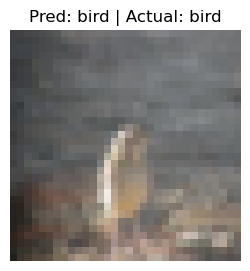

In [39]:
plt.figure(figsize=(3, 3))
plt.imshow(test_image)
plt.title(f"Pred: {class_names[predicted_class]} | Actual: {class_names[actual_class]}")
plt.axis('off')
plt.show()